In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from drtrex.instrument import Instrument
import scipp.constants as const
from scippneutron.tof import chopper_cascade

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(1.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
res = trex.run()

In [2]:
toa = trex.estimate_toa_at("Monitor at Sample", res)

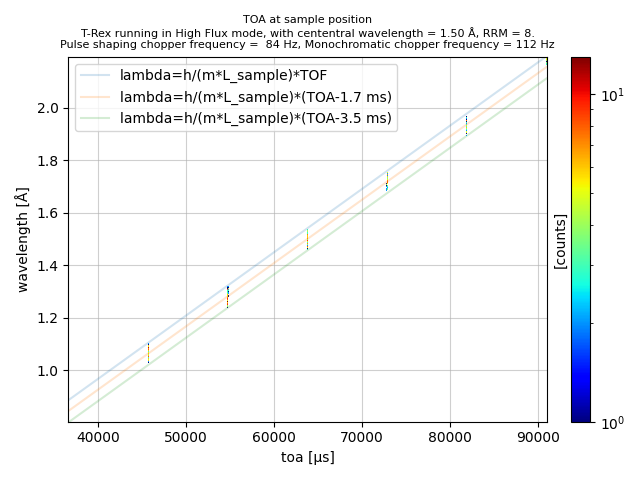

In [3]:
fig, ax = plt.subplots()
# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]
toa_sample = events_at_sample.hist(wavelength=800, toa=1500).plot(
    norm="log", cbar=True, ax=ax, cmap="jet"
)
ax.set_title("TOA at sample position\n" + str(trex), fontsize=8)


def wavelength_vs_toa(time, time_offset=sc.scalar(0.0, unit="ms")):
    return (
        const.h
        / const.m_n
        / trex.monitors["Monitor at Sample"].distance
        * (time - time_offset.to(unit="us"))
    ).to(unit="Å")


# TOF line
tof = sc.linspace("tof", toa.min(), toa.max(), 100, unit="ms").to(unit="us")
ax.plot(tof, wavelength_vs_toa(tof), label="lambda=h/(m*L_sample)*TOF", alpha=0.2)

# TOA line
ax.plot(
    tof,
    wavelength_vs_toa(tof, trex.t_offset),
    label="lambda=h/(m*L_sample)*(TOA-1.7 ms)",
    alpha=0.2,
)

ax.plot(
    tof,
    wavelength_vs_toa(tof, sc.scalar(3.5, unit="ms")),
    label="lambda=h/(m*L_sample)*(TOA-3.5 ms)",
    alpha=0.2,
)

ax.legend()
ax.grid(alpha=0.6)
fig.tight_layout()

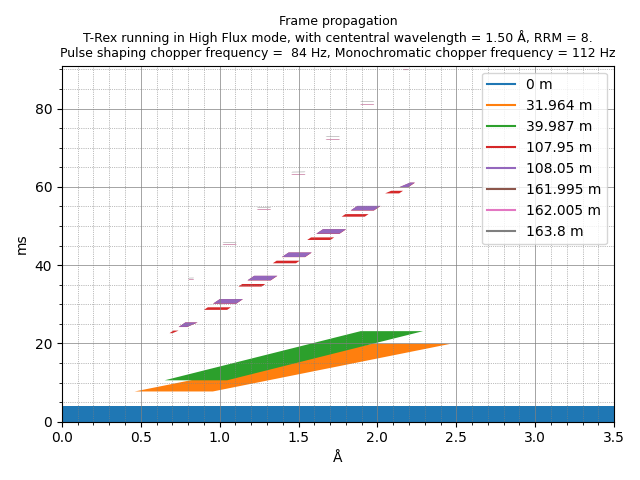

In [4]:
frames = chopper_cascade.FrameSequence.from_source_pulse(
    time_min=sc.scalar(0.0, unit="ms"),
    time_max=sc.scalar(4.0, unit="ms"),  # ESS pulse is 3 ms, but it has a tail
    wavelength_min=sc.scalar(0.0, unit="angstrom"),
    wavelength_max=sc.scalar(3.5, unit="angstrom"),
)
frames = frames.chop(trex.chopper_cascade.values())
at_sample = frames.propagate_to(trex.monitors["Monitor at Sample"].distance)

fig, ax = at_sample.draw(transpose=True)
ax.set_title("Frame propagation\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

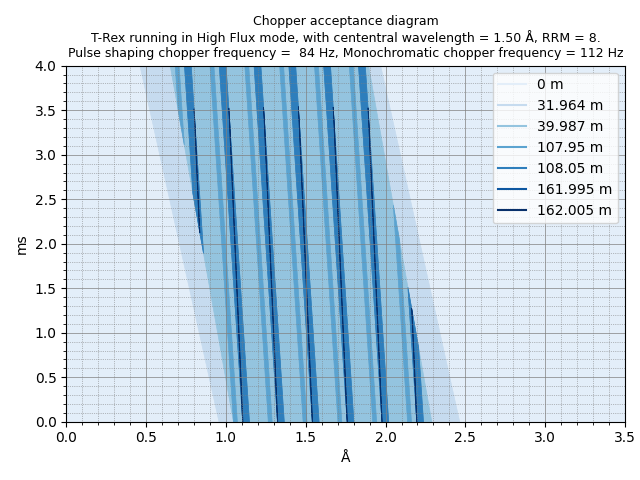

In [5]:
fig, ax = frames.acceptance_diagram()
ax.set_title("Chopper acceptance diagram\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

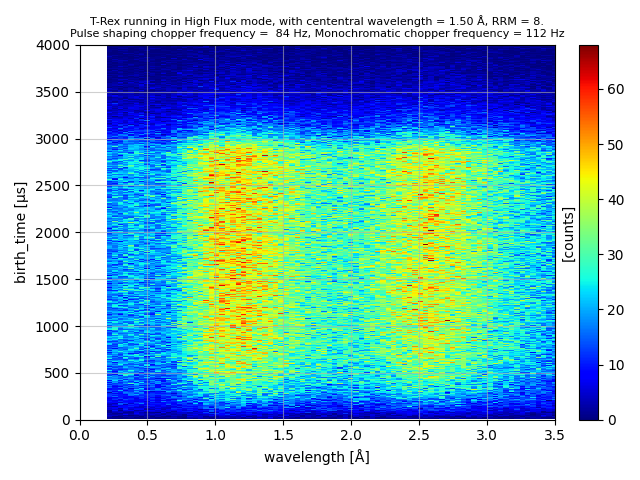

In [6]:
fig, ax = plt.subplots()
p = trex.source.data.hist(birth_time=500, wavelength=500).plot(cmap="jet", ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.set_xlim([0, 3.5])
ax.set_ylim([0, 4000])
ax.grid(alpha=0.6)
fig.tight_layout()

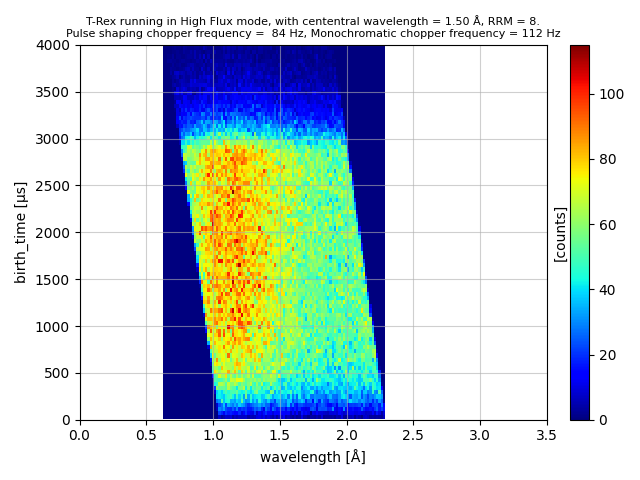

In [7]:
mask = trex.mask_from_choppers("Bandwidth Chopper 2")
trex.source.apply_mask(mask)

fig, ax = plt.subplots()
p = trex.source.data.hist(birth_time=100, wavelength=100).plot(cmap="jet", ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.set_xlim([0, 3.5])
ax.set_ylim([0, 4000])
ax.grid(alpha=0.6)
fig.tight_layout()

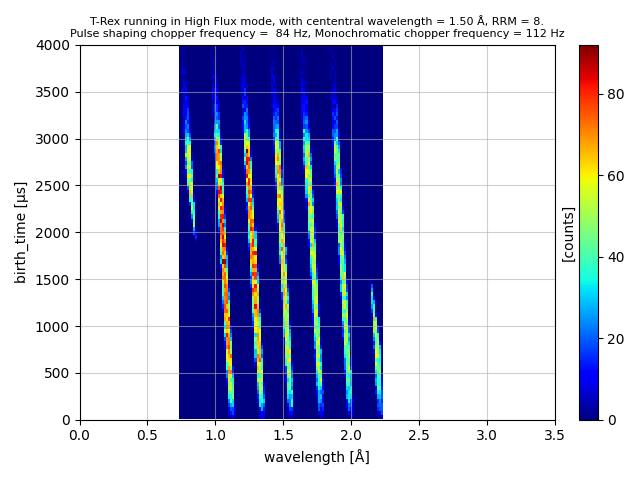

In [8]:
mask = trex.mask_from_choppers("Pulse Shaping Chopper 2")
trex.source.apply_mask(mask)

fig, ax = plt.subplots()
p = trex.source.data.hist(birth_time=100, wavelength=100).plot(cmap="jet", ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.set_xlim([0, 3.5])
ax.set_ylim([0, 4000])
ax.grid(alpha=0.6)
fig.tight_layout()

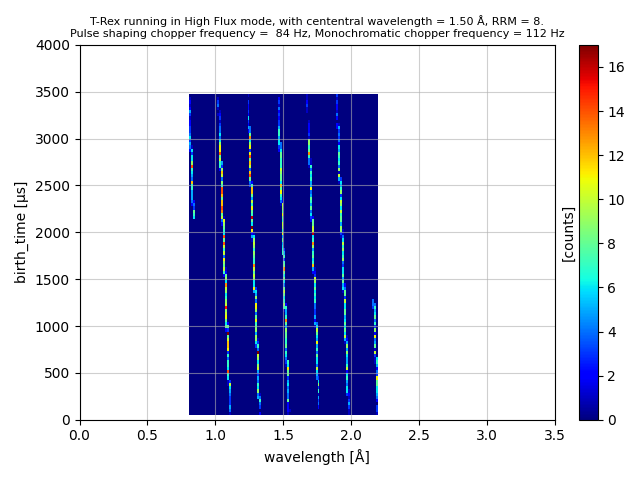

In [9]:
mask = trex.mask_from_choppers("Monochromatic Chopper 2")
trex.source.apply_mask(mask)

fig, ax = plt.subplots()
p = trex.source.data.hist(birth_time=100, wavelength=100).plot(cmap="jet", ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.set_xlim([0, 3.5])
ax.set_ylim([0, 4000])
ax.grid(alpha=0.6)
fig.tight_layout()